## Are they difference in income distribution across San Diego?

### Settings

In [33]:
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))

from pipeline.settings_generator import *
import json

### Income distribution (ACS B19001 / B19013, City of San Diego)

In [34]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from dotenv import load_dotenv
from census import Census

load_dotenv(".env")
api_key = os.getenv("CENSUS_API_KEY")
if not api_key:
    raise ValueError(
        "CENSUS_API_KEY not found. Add it to .env in root "
        "(get a free key at https://api.census.gov/data/key_signup.html)."
    )

client = Census(api_key)

STATE_FIPS = "06"
COUNTY_FIPS = "073"  # San Diego County
ACS_YEAR = 2020      # matches the ACS vintage used elsewhere in pipeline/data_generator.py

CACHE_DIR = Path("data/acs_tracts")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

In [35]:
# ACS table B19001: household count by income bracket -- gives the actual
# distribution (not just a single summary statistic) at tract level.
INCOME_BRACKETS = {
    "B19001_002E": "<$10k",
    "B19001_003E": "$10k-15k",
    "B19001_004E": "$15k-20k",
    "B19001_005E": "$20k-25k",
    "B19001_006E": "$25k-30k",
    "B19001_007E": "$30k-35k",
    "B19001_008E": "$35k-40k",
    "B19001_009E": "$40k-45k",
    "B19001_010E": "$45k-50k",
    "B19001_011E": "$50k-60k",
    "B19001_012E": "$60k-75k",
    "B19001_013E": "$75k-100k",
    "B19001_014E": "$100k-125k",
    "B19001_015E": "$125k-150k",
    "B19001_016E": "$150k-200k",
    "B19001_017E": "$200k+",
}

bracket_cache_file = CACHE_DIR / f"acs_{STATE_FIPS}{COUNTY_FIPS}_b19001_tracts.parquet"

if bracket_cache_file.exists():
    income_brackets = pd.read_parquet(bracket_cache_file)
else:
    raw = client.acs5.get(
        list(INCOME_BRACKETS),
        geo={"for": "tract:*", "in": f"state:{STATE_FIPS} county:{COUNTY_FIPS}"},
        year=ACS_YEAR,
    )
    income_brackets = pd.DataFrame(raw)
    income_brackets[list(INCOME_BRACKETS)] = income_brackets[list(INCOME_BRACKETS)].astype(float)
    income_brackets["GEOID"] = income_brackets["state"] + income_brackets["county"] + income_brackets["tract"]
    income_brackets = income_brackets.set_index("GEOID")[list(INCOME_BRACKETS)]
    income_brackets.to_parquet(bracket_cache_file)

income_brackets.head()

,B19001_002E,B19001_003E,B19001_004E,B19001_005E,B19001_006E,B19001_007E,B19001_008E,B19001_009E,B19001_010E,B19001_011E,B19001_012E,B19001_013E,B19001_014E,B19001_015E,B19001_016E,B19001_017E
GEOID,,,,,,,,,,,,,,,,
06073017064,0.0,0.0,0.0,0.0,0.0,67.0,0.0,0.0,0.0,139.0,56.0,248.0,198.0,340.0,282.0,1013.0
06073017065,57.0,0.0,101.0,49.0,20.0,78.0,12.0,0.0,0.0,118.0,46.0,142.0,161.0,306.0,299.0,1351.0
06073017066,0.0,0.0,0.0,0.0,0.0,80.0,139.0,0.0,0.0,110.0,0.0,66.0,461.0,58.0,156.0,478.0
06073017067,39.0,30.0,0.0,16.0,0.0,0.0,12.0,17.0,0.0,47.0,43.0,12.0,40.0,136.0,42.0,389.0
06073017068,68.0,0.0,0.0,54.0,77.0,0.0,0.0,27.0,17.0,49.0,129.0,493.0,132.0,344.0,160.0,275.0


In [36]:
# ACS table B19013: median household income per tract, for a spatial view.
median_cache_file = CACHE_DIR / f"acs_{STATE_FIPS}{COUNTY_FIPS}_b19013_tracts.parquet"

if median_cache_file.exists():
    median_income = pd.read_parquet(median_cache_file)
else:
    raw = client.acs5.get(
        ["B19013_001E"],
        geo={"for": "tract:*", "in": f"state:{STATE_FIPS} county:{COUNTY_FIPS}"},
        year=ACS_YEAR,
    )
    median_income = pd.DataFrame(raw)
    median_income["B19013_001E"] = median_income["B19013_001E"].astype(float)
    # Census uses -666666666 as a sentinel for tracts with too small a sample
    # to estimate; treat those as missing rather than a real dollar value.
    median_income.loc[median_income["B19013_001E"] < 0, "B19013_001E"] = pd.NA
    median_income["GEOID"] = median_income["state"] + median_income["county"] + median_income["tract"]
    median_income = median_income.set_index("GEOID")[["B19013_001E"]]
    median_income.to_parquet(median_cache_file)

median_income = median_income.rename(columns={"B19013_001E": "median_household_income"})
median_income.head()

,median_household_income
GEOID,
06073017064,163139.0
06073017065,181731.0
06073017066,119455.0
06073017067,196797.0
06073017068,99830.0


In [37]:
# The Census API only takes county/state/tract geographies, but data/san_diego.geojson
# (used everywhere else in this project, e.g. config['geodata_path']) covers just the
# City of San Diego -- a subset of San Diego County's tracts. Dissolve those block
# geometries up to tracts and use that set to scope both income tables consistently
# with the rest of the pipeline, rather than reporting county-wide numbers.
blocks = gpd.read_file("../data/san_diego.geojson")[["GEOID", "geometry"]]
blocks["tract_geoid"] = blocks["GEOID"].str[:11]
tracts = blocks.dissolve(by="tract_geoid").reset_index()

city_tract_ids = tracts["tract_geoid"]
county_tract_count = len(median_income)
income_brackets = income_brackets.loc[income_brackets.index.intersection(city_tract_ids)]
median_income = median_income.loc[median_income.index.intersection(city_tract_ids)]

print(f"{len(city_tract_ids)} tracts in San Diego (of {county_tract_count} fetched county-wide)")

363 tracts in San Diego (of 737 fetched county-wide)


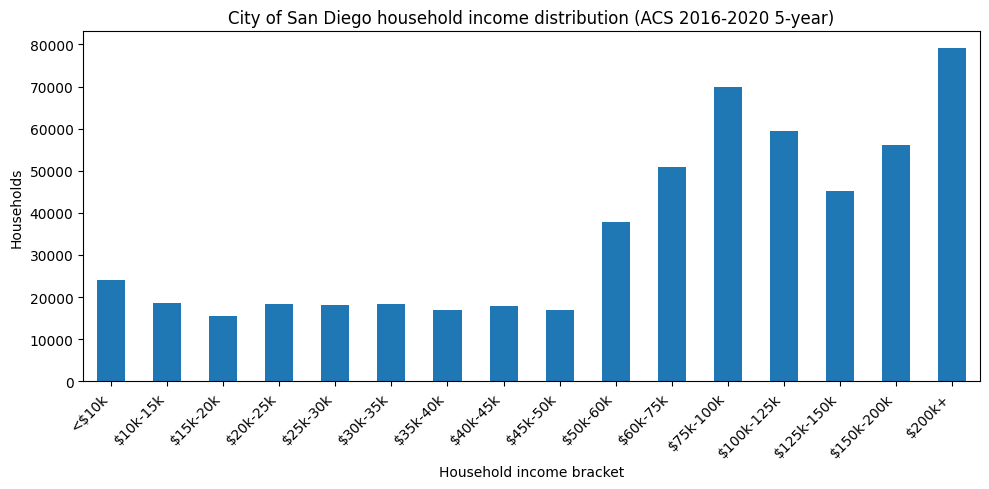

In [38]:
# City-wide distribution: households by income bracket, summed across San Diego's tracts.
bracket_totals = income_brackets.sum().rename(index=INCOME_BRACKETS)

fig, ax = plt.subplots(figsize=(10, 5))
bracket_totals.plot(kind="bar", ax=ax)
ax.set_ylabel("Households")
ax.set_xlabel("Household income bracket")
ax.set_title("City of San Diego household income distribution (ACS 2016-2020 5-year)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

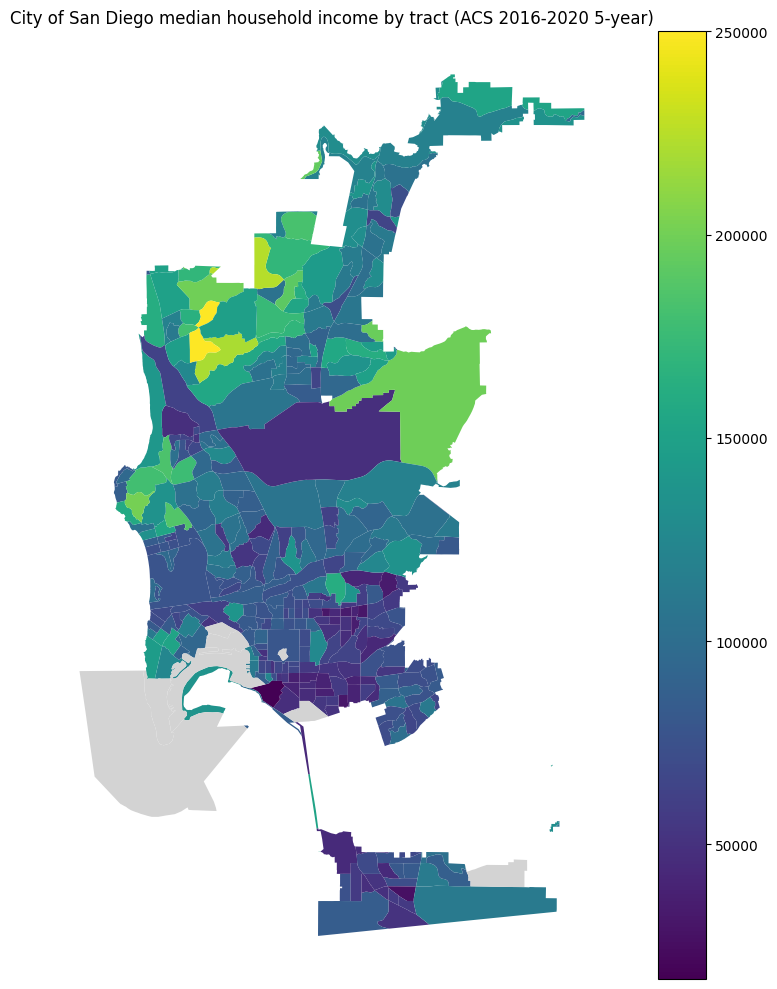

In [39]:
# Join median household income onto the (already city-scoped) tract geometries.
tracts_income = tracts.merge(median_income, left_on="tract_geoid", right_index=True, how="left")

fig, ax = plt.subplots(figsize=(10, 10))
tracts_income.plot(
    column="median_household_income",
    cmap="viridis",
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "no data"},
    ax=ax,
)
ax.set_title("City of San Diego median household income by tract (ACS 2016-2020 5-year)")
ax.axis("off")
plt.tight_layout()
plt.show()

### % of households earning $100k+ per bloc (ACS B19001 race iterations)

ACS publishes race/ethnicity iterations of B19001 (household income brackets) using
the same table structure with a letter suffix. These line up with the blocs already
used elsewhere in the pipeline:

| Bloc | ACS iteration | Definition |
|---|---|---|
| W | B19001**H** | White alone, not Hispanic |
| B | B19001**B** | Black alone |
| H | B19001**I** | Hispanic or Latino (any race) |
| A | B19001**D** | Asian alone |

"$100k+" is the sum of brackets 014E-017E (`$100k-125k`, `$125k-150k`, `$150k-200k`,
`$200k+`), divided by each bloc's total households (001E), summed across the
city-scoped tracts (`city_tract_ids`) already computed above.

In [40]:
BLOC_ACS_SUFFIX = {"W": "H", "B": "B", "H": "I", "A": "D"}
BLOC_LABELS = {"W": "White", "B": "Black", "H": "Hispanic/Latino", "A": "Asian"}
HIGH_INCOME_BRACKETS = ["014E", "015E", "016E", "017E"]  # $100k-125k and up

def fetch_bloc_brackets(suffix):
    """Fetch (or load cached) B19001<suffix> household-income brackets by tract."""
    table = f"B19001{suffix}"
    cache_file = CACHE_DIR / f"acs_{STATE_FIPS}{COUNTY_FIPS}_{table.lower()}_tracts.parquet"

    if cache_file.exists():
        return pd.read_parquet(cache_file)

    var_codes = [f"{table}_{n:03d}E" for n in range(1, 18)]
    raw = client.acs5.get(
        var_codes,
        geo={"for": "tract:*", "in": f"state:{STATE_FIPS} county:{COUNTY_FIPS}"},
        year=ACS_YEAR,
    )
    df = pd.DataFrame(raw)
    df[var_codes] = df[var_codes].astype(float)
    df["GEOID"] = df["state"] + df["county"] + df["tract"]
    df = df.set_index("GEOID")[var_codes]
    df.to_parquet(cache_file)
    return df

bloc_high_income_pct = {}
for bloc, suffix in BLOC_ACS_SUFFIX.items():
    table = f"B19001{suffix}"
    bloc_brackets = fetch_bloc_brackets(suffix)
    bloc_brackets = bloc_brackets.loc[bloc_brackets.index.intersection(city_tract_ids)]

    total_households = bloc_brackets[f"{table}_001E"].sum()
    high_income_households = bloc_brackets[[f"{table}_{code}" for code in HIGH_INCOME_BRACKETS]].sum().sum()
    bloc_high_income_pct[bloc] = 100 * high_income_households / total_households

bloc_high_income_pct = pd.Series(bloc_high_income_pct, name="pct_100k_plus")
bloc_high_income_pct

W    48.621415
B    23.684830
H    28.135971
A    50.663035
Name: pct_100k_plus, dtype: float64

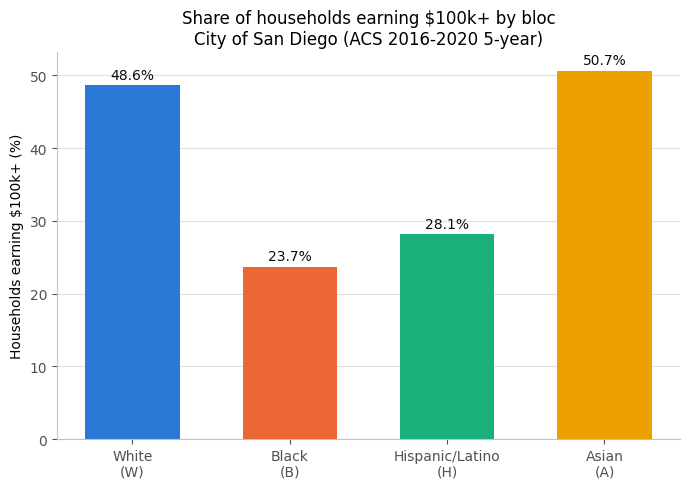

In [41]:
BLOC_COLORS = {"W": "#2a78d6", "B": "#eb6834", "H": "#1baf7a", "A": "#eda100"}

fig, ax = plt.subplots(figsize=(7, 5))
blocs = list(BLOC_ACS_SUFFIX)
values = [bloc_high_income_pct[b] for b in blocs]
colors = [BLOC_COLORS[b] for b in blocs]
labels = [f"{BLOC_LABELS[b]}\n({b})" for b in blocs]

bars = ax.bar(labels, values, color=colors, width=0.6)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{value:.1f}%", ha="center", va="bottom", color="#0b0b0b", fontsize=10)

ax.set_ylabel("Households earning $100k+ (%)")
ax.set_title("Share of households earning $100k+ by bloc\nCity of San Diego (ACS 2016-2020 5-year)")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Household counts by bracket, per bloc (raw counts)

Same shape as the city-wide bar chart above (`bracket_totals`), but split one
panel per bloc instead of normalizing to a % share. Each bloc has a very
different total household count, so the panels use their own y-scale rather
than a single shared axis -- the point here is each bloc's raw bracket shape,
not a size comparison across blocs (see the % chart above for that).

In [44]:
bloc_bracket_totals = {}
for bloc, suffix in BLOC_ACS_SUFFIX.items():
    table = f"B19001{suffix}"
    bloc_brackets = fetch_bloc_brackets(suffix)
    bloc_brackets = bloc_brackets.loc[bloc_brackets.index.intersection(city_tract_ids)]
    bloc_bracket_totals[bloc] = bloc_brackets[[f"{table}_{code}" for code in BRACKET_CODES]].sum().values

bloc_bracket_totals = pd.DataFrame(bloc_bracket_totals, index=BRACKET_LABELS)
bloc_bracket_totals

,W,B,H,A
<$10k,10878.0,2378.0,5137.0,4587.0
$10k-15k,7835.0,2282.0,5711.0,2291.0
$15k-20k,6812.0,1437.0,5056.0,1815.0
$20k-25k,8397.0,1822.0,5998.0,1685.0
$25k-30k,8490.0,1492.0,5790.0,1846.0
$30k-35k,7457.0,1506.0,6479.0,2433.0
$35k-40k,7481.0,1490.0,5727.0,1856.0
$40k-45k,8558.0,1647.0,5438.0,1995.0
$45k-50k,7902.0,1351.0,5615.0,1745.0
$50k-60k,17082.0,2803.0,11960.0,4721.0


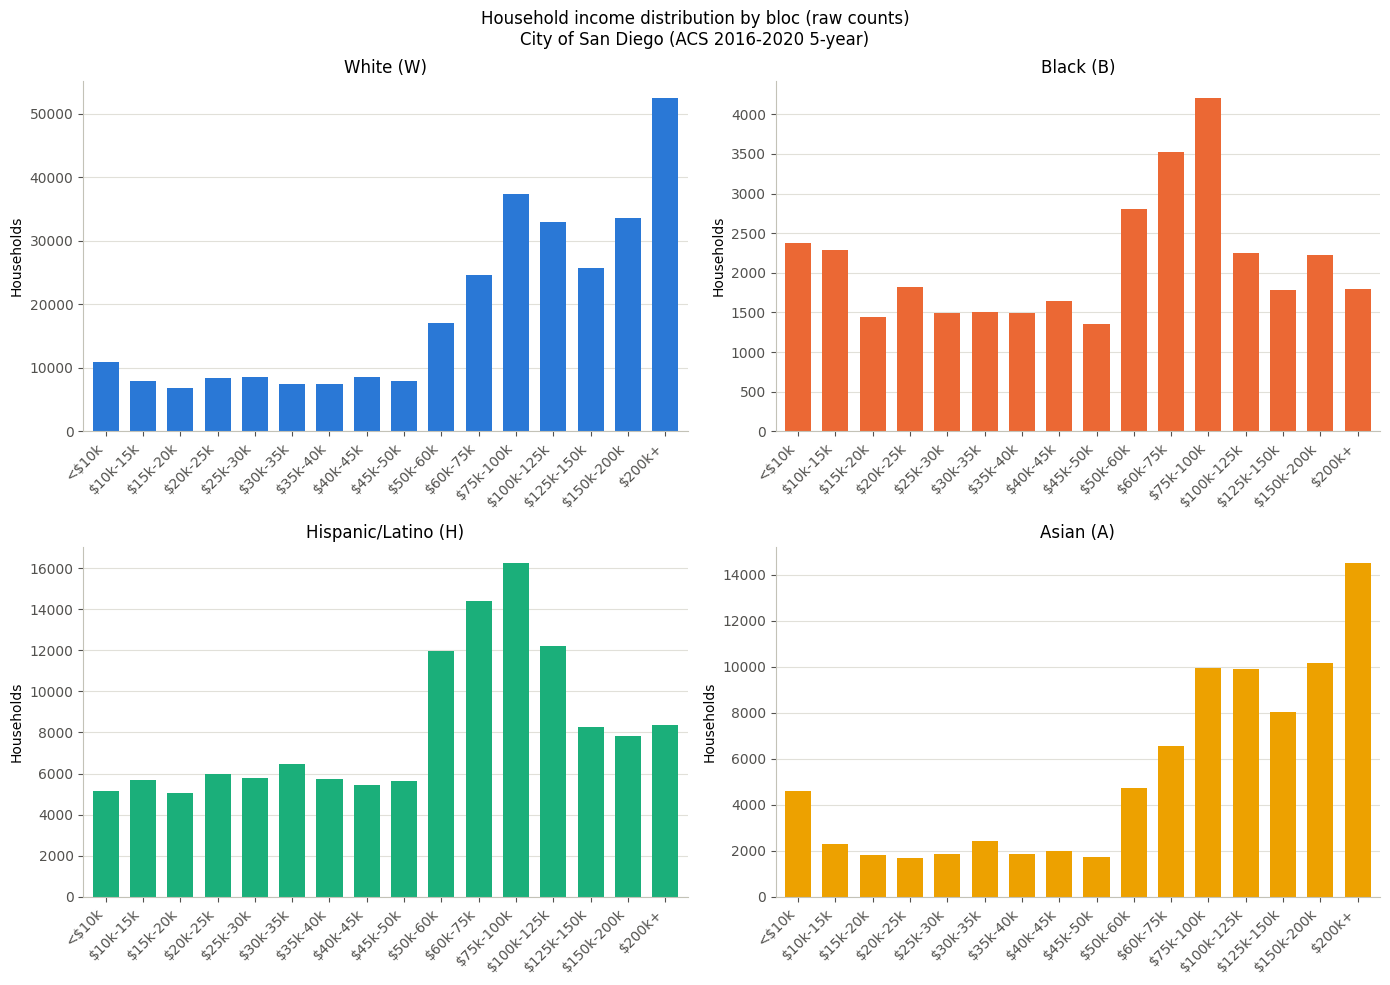

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, bloc in zip(axes.flat, BLOC_ACS_SUFFIX):
    bloc_bracket_totals[bloc].plot(kind="bar", ax=ax, color=BLOC_COLORS[bloc], width=0.7)
    ax.set_title(f"{BLOC_LABELS[bloc]} ({bloc})")
    ax.set_ylabel("Households")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#c3c2b7")
    ax.tick_params(axis="x", rotation=45, colors="#52514e")
    ax.tick_params(axis="y", colors="#52514e")
    for tick in ax.get_xticklabels():
        tick.set_ha("right")
    ax.yaxis.grid(True, color="#e1e0d9", linewidth=0.8)
    ax.set_axisbelow(True)

fig.suptitle("Household income distribution by bloc (raw counts)\nCity of San Diego (ACS 2016-2020 5-year)")
plt.tight_layout()
plt.show()